## Train a simple convnet on the Fashion MNIST dataset

In this, we will see how to deal with image data and train a convnet for image classification task.

### Load the  `fashion_mnist`  dataset

** Use keras.datasets to load the dataset **

In [1]:
from keras.datasets import fashion_mnist
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

Using TensorFlow backend.


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Find no.of samples are there in training and test datasets

In [3]:
!ls -l


total 8
drwx------ 3 root root 4096 Aug 18 10:59 drive
drwxr-xr-x 1 root root 4096 Aug  2 16:06 sample_data


In [4]:
x_train.shape

(60000, 28, 28)

In [5]:
x_test.shape

(10000, 28, 28)

### Find dimensions of an image in the dataset

In [6]:
x_train[0].shape

(28, 28)

In [7]:
x_test[0].shape

(28, 28)

### Convert train and test labels to one hot vectors

** check `keras.utils.to_categorical()` **

In [0]:
import numpy as np
import tensorflow as tf
tf.reset_default_graph()
tf.set_random_seed(42)


In [0]:
import keras

In [10]:
np.unique(y_test)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8)

In [0]:
y_train = tf.keras.utils.to_categorical(y_train, num_classes=10)
y_test = tf.keras.utils.to_categorical(y_test, num_classes=10)

### Normalize both the train and test image data from 0-255 to 0-1

In [12]:
x_train[0]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   1,
          0,   0,  13,  73,   0,   0,   1,   4,   0,   0,   0,   0,   1,
          1,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
          0,  36, 136, 127,  62,  54,   0,   0,   0,   1,   3,   4,   0,
          0,   3],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   6,
          0, 102, 204, 176, 134, 144, 123,  23,   0,   0,   0,   0,  12,
         10,   0],
       [  

In [13]:
x_train=x_train/255
x_train=x_train.astype('float32')
x_train[0]

array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.    

In [14]:
x_test=x_test/255
x_test=x_test.astype('float32')
x_test[0]

array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.    

### Reshape the data from 28x28 to 28x28x1 to match input dimensions in Conv2D layer in keras

In [0]:
tf.keras.backend.clear_session()
#Initialize model, reshape & normalize data
x_train=x_train.reshape((60000, 28, 28,1))
x_test=x_test.reshape((10000, 28, 28,1))
model = tf.keras.models.Sequential()

#Reshape data from 2D (28,28) to 3D (28, 28, 1)
#model.add(tf.keras.layers.Reshape((28,28,1),input_shape=(28,28,)))

#normalize data
#model.add(tf.keras.layers.BatchNormalization())

### Import the necessary layers from keras to build the model

### Build a model 

** with 2 Conv layers having `32 3x3 filters` in both convolutions with `relu activations` and `flatten` before passing the feature map into 2 fully connected layers (or Dense Layers) having 128 and 10 neurons with `relu` and `softmax` activations respectively. Now, using `categorical_crossentropy` loss with `adam` optimizer train the model with early stopping `patience=5` and no.of `epochs=10`. **

In [16]:
#Add first convolutional layer
model.add(tf.keras.layers.Conv2D(32, #Number of filters 
                                 kernel_size=(3,3), #Size of the filter
                                 activation='relu',input_shape=(28,28,1)))

#Add second convolutional layer
model.add(tf.keras.layers.Conv2D(32, kernel_size=(3,3), activation='relu'))

#Flatten the output
model.add(tf.keras.layers.Flatten())

#Dense layer
model.add(tf.keras.layers.Dense(128, activation='relu'))

#Output layer
model.add(tf.keras.layers.Dense(10, activation='softmax'))
#model.add(tf.keras.layers.Activation('softmax'))

W0818 11:43:00.332000 139927076030336 deprecation.py:506] From /usr/local/lib/python3.6/dist-packages/tensorflow/python/ops/init_ops.py:1251: calling VarianceScaling.__init__ (from tensorflow.python.ops.init_ops) with dtype is deprecated and will be removed in a future version.
Instructions for updating:
Call initializer instance with the dtype argument instead of passing it to the constructor


In [0]:
model.compile(optimizer='adam', 
              loss='categorical_crossentropy', metrics=['accuracy'])

In [18]:
model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d (Conv2D)              (None, 26, 26, 32)        320       
_________________________________________________________________
conv2d_1 (Conv2D)            (None, 24, 24, 32)        9248      
_________________________________________________________________
flatten (Flatten)            (None, 18432)             0         
_________________________________________________________________
dense (Dense)                (None, 128)               2359424   
_________________________________________________________________
dense_1 (Dense)              (None, 10)                1290      
Total params: 2,370,282
Trainable params: 2,370,282
Non-trainable params: 0
_________________________________________________________________


In [0]:
chpt = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, verbose=0, mode='auto')

In [20]:
#Train the model
model.fit(x_train,y_train,validation_data=(x_test,y_test),epochs=10,batch_size=10000, callbacks=[chpt] )

Train on 60000 samples, validate on 10000 samples
Epoch 1/10
60000/60000 [==============================] - 6s 107us/sample - loss: 1.5770 - acc: 0.4771 - val_loss: 1.1179 - val_acc: 0.6798
Epoch 2/10
60000/60000 [==============================] - 2s 31us/sample - loss: 0.9773 - acc: 0.6936 - val_loss: 0.8979 - val_acc: 0.7251
Epoch 3/10
60000/60000 [==============================] - 2s 31us/sample - loss: 0.7645 - acc: 0.7359 - val_loss: 0.6961 - val_acc: 0.7568
Epoch 4/10
60000/60000 [==============================] - 2s 31us/sample - loss: 0.6453 - acc: 0.7681 - val_loss: 0.6056 - val_acc: 0.7783
Epoch 5/10
60000/60000 [==============================] - 2s 31us/sample - loss: 0.5660 - acc: 0.7969 - val_loss: 0.5559 - val_acc: 0.7972
Epoch 6/10
60000/60000 [==============================] - 2s 31us/sample - loss: 0.5118 - acc: 0.8153 - val_loss: 0.5125 - val_acc: 0.8157
Epoch 7/10
60000/60000 [==============================] - 2s 31us/sample - loss: 0.4718 - acc: 0.8352 - val_loss: 0

### Now, to the above model add `max` pooling layer of `filter size 2x2` and `dropout` layer with `p=0.25` after the 2 conv layers and run the model

In [0]:
tf.keras.backend.clear_session()

#Initialize model, reshape & normalize data
model2 = tf.keras.models.Sequential()

#Reshape data from 2D (28,28) to 3D (28, 28, 1)
#model2.add(tf.keras.layers.Reshape((28,28,1),input_shape=(28,28,)))

#normalize data
#model2.add(tf.keras.layers.BatchNormalization())

#Add first convolutional layer
model2.add(tf.keras.layers.Conv2D(32, #Number of filters 
                                 kernel_size=(3,3), #Size of the filter
                                 activation='relu',input_shape=(28,28,1)))

#Add second convolutional layer
model2.add(tf.keras.layers.Conv2D(32, kernel_size=(3,3), activation='relu'))

#Add MaxPooling layer
model2.add(tf.keras.layers.MaxPool2D(pool_size=(2,2)))


#Flatten the output
model2.add(tf.keras.layers.Flatten())

#Add another dropout layer
model2.add(tf.keras.layers.Dropout(0.25))

#Dense layer
model2.add(tf.keras.layers.Dense(128, activation='relu'))

#Output layer
model2.add(tf.keras.layers.Dense(10, activation='softmax'))
#model.add(tf.keras.layers.Activation('softmax'))


In [0]:
model2.compile(optimizer='adam', 
              loss='categorical_crossentropy', metrics=['accuracy'])

In [23]:
model2.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d (Conv2D)              (None, 26, 26, 32)        320       
_________________________________________________________________
conv2d_1 (Conv2D)            (None, 24, 24, 32)        9248      
_________________________________________________________________
max_pooling2d (MaxPooling2D) (None, 12, 12, 32)        0         
_________________________________________________________________
flatten (Flatten)            (None, 4608)              0         
_________________________________________________________________
dropout (Dropout)            (None, 4608)              0         
_________________________________________________________________
dense (Dense)                (None, 128)               589952    
_________________________________________________________________
dense_1 (Dense)              (None, 10)                1

In [0]:
chpt = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, verbose=0, mode='auto')

In [25]:
x_train.shape

(60000, 28, 28, 1)

In [26]:
#Train the model
model2.fit(x_train,y_train,epochs=10,batch_size=10000, callbacks=[chpt] )

Epoch 1/10
50000/60000 [========================>.....] - ETA: 0s - loss: 1.9253 - acc: 0.4501

W0818 11:43:27.333055 139927076030336 callbacks.py:1259] Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: loss,acc


60000/60000 [==============================] - 2s 29us/sample - loss: 1.8154 - acc: 0.4878
Epoch 2/10
50000/60000 [========================>.....] - ETA: 0s - loss: 0.8832 - acc: 0.7160

W0818 11:43:29.019680 139927076030336 callbacks.py:1259] Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: loss,acc


60000/60000 [==============================] - 2s 28us/sample - loss: 0.8582 - acc: 0.7195
Epoch 3/10
50000/60000 [========================>.....] - ETA: 0s - loss: 0.6998 - acc: 0.7495

...

60000/60000 [==============================] - 2s 28us/sample - loss: 0.4555 - acc: 0.8393
Epoch 9/10
50000/60000 [========================>.....] - ETA: 0s - loss: 0.4387 - acc: 0.8440

W0818 11:43:40.885744 139927076030336 callbacks.py:1259] Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: loss,acc


60000/60000 [==============================] - 2s 28us/sample - loss: 0.4378 - acc: 0.8444
Epoch 10/10
50000/60000 [========================>.....] - ETA: 0s - loss: 0.4231 - acc: 0.8517

W0818 11:43:42.575134 139927076030336 callbacks.py:1259] Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: loss,acc


60000/60000 [==============================] - 2s 28us/sample - loss: 0.4226 - acc: 0.8520


### Now, to the above model, lets add Data Augmentation 

### Import the ImageDataGenrator from keras and fit the training images

In [0]:
model3=model2
x_train1=x_train
y_train1=y_train
x_test1=x_test
y_test1=y_test

In [0]:
#img_generator= tf.keras.preprocessing.image.ImageDataGenerator(rotation_range=20,
#                                                                   width_shift_range=0.2,
#                                                                   height_shift_range=0.2,
#                                                                   horizontal_flip=True)
datagen = tf.keras.preprocessing.image.ImageDataGenerator(rotation_range=40,
        width_shift_range=0.2,
        height_shift_range=0.2,
        shear_range=0.2,
        zoom_range=0.2,
        horizontal_flip=True,
        fill_mode='nearest')


#### Showing 5 versions of the first image in training dataset using image datagenerator.flow()

In [29]:
x_train1.shape

(60000, 28, 28, 1)

In [30]:
x_test1.shape

(10000, 28, 28, 1)

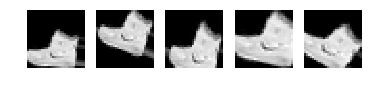

In [31]:
from matplotlib import pyplot as plt
gen = datagen.flow(x_train1[0:1], batch_size=1)
for i in range(1, 6):
    plt.subplot(1,5,i)
    plt.axis("off")
    plt.imshow(gen.next().squeeze(), cmap='gray')
    plt.plot()
plt.show()

### Run the above model using fit_generator()

In [0]:
# x_test1=x_test1.reshape((10000, 28, 28,1))

In [0]:
# datagen.fit(x_train1)

In [34]:
model2.fit_generator(datagen.flow(x_train1, y_train1, batch_size = 32),
 validation_data = (x_test1, y_test1), steps_per_epoch = len(x_train1) // 32,
 epochs = 10)

#model.fit_generator(datagen.flow(x_train, y_train, batch_size=32),
#                    steps_per_epoch=len(x_train) / 32, epochs=epochs)

Epoch 1/10
1875/1875 [==============================] - 22s 12ms/step - loss: 1.0043 - acc: 0.6306 - val_loss: 0.6167 - val_acc: 0.7684
Epoch 2/10
1875/1875 [==============================] - 22s 12ms/step - loss: 0.7427 - acc: 0.7231 - val_loss: 0.5872 - val_acc: 0.7736
Epoch 3/10
1875/1875 [==============================] - 23s 12ms/step - loss: 0.6696 - acc: 0.7482 - val_loss: 0.6008 - val_acc: 0.7760
Epoch 4/10
1875/1875 [==============================] - 22s 12ms/step - loss: 0.6288 - acc: 0.7649 - val_loss: 0.6083 - val_acc: 0.7865
Epoch 5/10
1875/1875 [==============================] - 23s 12ms/step - loss: 0.5982 - acc: 0.7772 - val_loss: 0.5861 - val_acc: 0.7935
Epoch 6/10
1875/1875 [==============================] - 23s 12ms/step - loss: 0.5717 - acc: 0.7875 - val_loss: 0.5093 - val_acc: 0.8138
Epoch 7/10
1875/1875 [==============================] - 23s 12ms/step - loss: 0.5566 - acc: 0.7949 - val_loss: 0.5442 - val_acc: 0.7991
Epoch 8/10
1875/1875 [==========================

###  Report the final train and validation accuracy

In [35]:
test_loss, test_acc = model2.evaluate(x_test1, y_test1)
print("The accuracy score after the introduction of Batch Normalization is")
print(test_acc)

10000/10000 [==============================] - 1s 78us/sample - loss: 0.5040 - acc: 0.8184
The accuracy score after the introduction of Batch Normalization is
0.8184


## **DATA AUGMENTATION ON CIFAR10 DATASET**

One of the best ways to improve the performance of a Deep Learning model is to add more data to the training set. Aside from gathering more instances from the wild that are representative of the distinction task, we want to develop a set of methods that enhance the data we already have. There are many ways to augment existing datasets and produce more robust models. In the image domain, these are done to utilize the full power of the convolutional neural network, which is able to capture translational invariance. This translational invariance is what makes image recognition such a difficult task in the first place. You want the dataset to be representative of the many different positions, angles, lightings, and miscellaneous distortions that are of interest to the vision task.

### **Import neessary libraries for data augmentation**

### **Load CIFAR10 dataset**

In [0]:
#from keras.datasets import cifar10
#(x_train, y_train), (x_test, y_test) = cifar10.load_data()

In [0]:
from keras.datasets import cifar10
(x1_train, y1_train), (x1_test, y1_test) = cifar10.load_data()

### **Create a data_gen funtion to genererator with image rotation,shifting image horizontally and vertically with random flip horizontally.**

In [0]:
datagen = tf.keras.preprocessing.image.ImageDataGenerator(
   featurewise_center=True,
   featurewise_std_normalization=True,
   rotation_range=20,
   width_shift_range=0.2,
   height_shift_range=0.2,
   horizontal_flip=True)
#image genator 
#reshape 
x1_train = x1_train.reshape(50000, 32, 32, 3)
x1_test = x1_test.reshape(10000, 32, 32, 3)
# compute quantities required for featurewise normalization
# (std, mean, and principal components if ZCA whitening is applied)



### **Prepare/fit the generator.**

In [0]:
datagen.fit(x1_train)  
from matplotlib import pyplot as plt

### **Generate 5 images for 1 of the image of CIFAR10 train dataset.**

In [0]:
from matplotlib import pyplot as plt

W0818 11:53:59.566173 139927076030336 image.py:648] Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
W0818 11:53:59.581326 139927076030336 image.py:648] Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
W0818 11:53:59.594546 139927076030336 image.py:648] Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
W0818 11:53:59.607270 139927076030336 image.py:648] Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
W0818 11:53:59.622672 139927076030336 image.py:648] Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


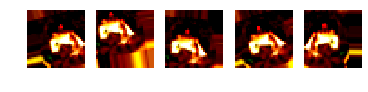

In [42]:
gen = datagen.flow(x1_train[0:1], batch_size=1)
for i in range(1, 6):
   plt.subplot(1,5,i)
   plt.axis("off")
   plt.imshow(gen.next().squeeze(), cmap='gray')
   plt.plot()
plt.show()